  Fetching NVDA...
  Fetching TSLA...
  Fetching SPY...
  Fetching QQQ...

Last 5 trading days:
                                 NVDA        TSLA         SPY         QQQ
Date                                                                     
2025-11-11 00:00:00-05:00  193.160004  439.619995  683.000000  621.570007
2025-11-12 00:00:00-05:00  193.800003  430.600006  683.380005  621.080017
2025-11-13 00:00:00-05:00  186.860001  401.989990  672.039978  608.400024
2025-11-14 00:00:00-05:00  190.169998  404.350006  671.929993  608.859985
2025-11-17 00:00:00-05:00  186.600006  408.920013  665.669983  603.659973

Returns: 249 days × 4 assets

Annualized Covariance Matrix:
          NVDA      TSLA       SPY       QQQ
NVDA  0.250312  0.165610  0.071484  0.094138
TSLA  0.165610  0.428396  0.087779  0.112423
SPY   0.071484  0.087779  0.038534  0.045244
QQQ   0.094138  0.112423  0.045244  0.056294

First principal component explains 76.9% of total variance
Weights in dominant market mode:
  NVDA:

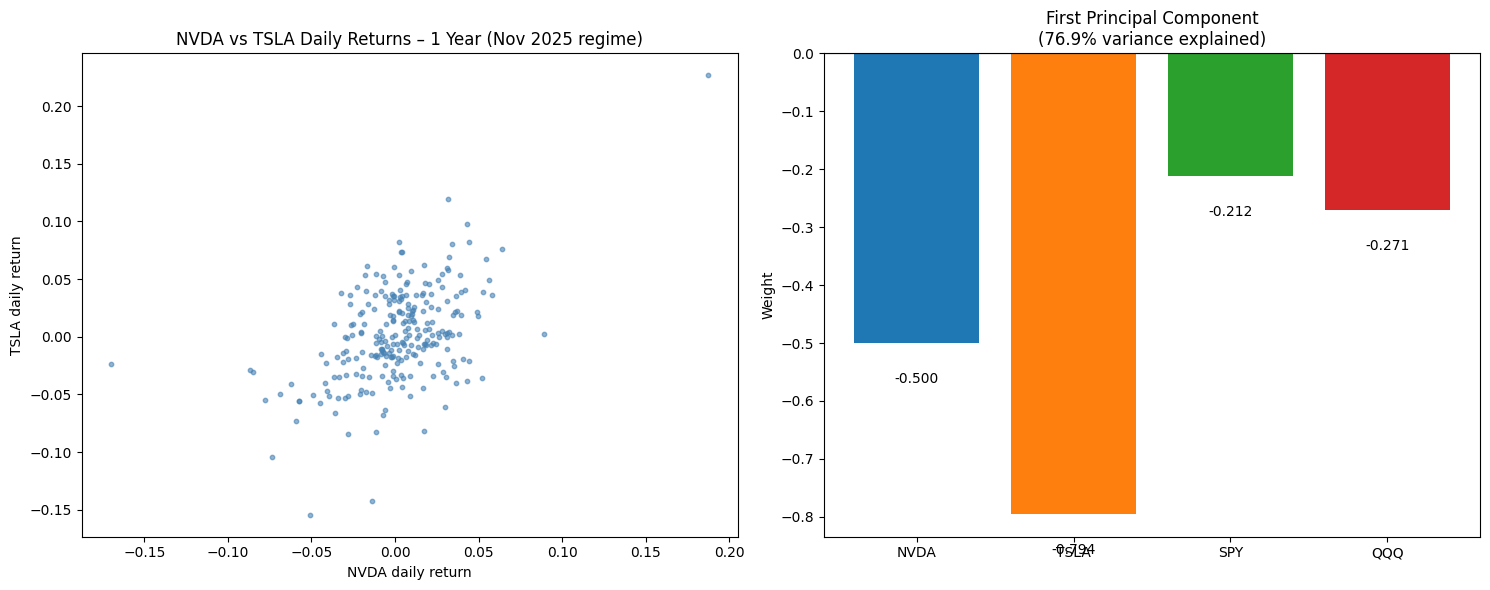

0.7710466823680023

Done. Commit the notebook + PNG to your roadtoquant repo right now.


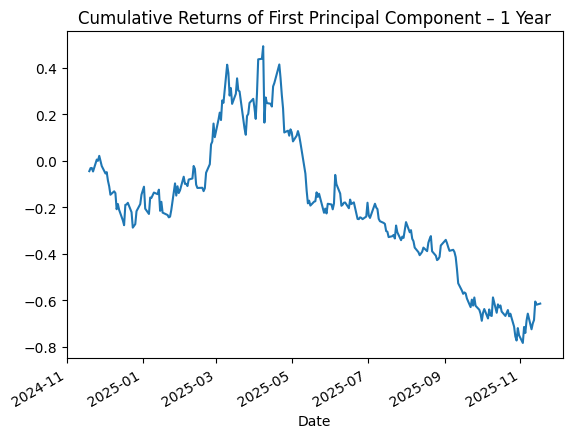

In [3]:
# roadtoquant – Week 1: Linear Algebra & PCA (VS Code guaranteed)
# Run in your existing environment – no Colab needed

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ['NVDA', 'TSLA', 'SPY', 'QQQ']
prices = pd.DataFrame()

print("Downloading data for each ticker individually (most reliable method)...")
for ticker in tickers:
    print(f"  Fetching {ticker}...")
    df = yf.Ticker(ticker).history(period="1y", auto_adjust=True)
    prices[ticker] = df['Close']   # auto_adjust=True handles dividends/splits

# Defensive cleaning
prices = prices.ffill().bfill()   # almost never needed, but safe
prices = prices.astype(float)

print("\nLast 5 trading days:")
print(prices.tail())

# === 2. Daily returns ===
returns = prices.pct_change().dropna()
print(f"\nReturns: {returns.shape[0]} days × {returns.shape[1]} assets")

# === 3. Annualized covariance (safe multiplication) ===
cov_matrix = returns.cov() * 252
print("\nAnnualized Covariance Matrix:")
print(cov_matrix.round(6))

# === 4. Eigen decomposition ===
eigvals, eigvecs = np.linalg.eig(cov_matrix.values)  # .values guarantees pure numpy array

# Sort descending
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

explained = eigvals[0] / eigvals.sum() * 100
print(f"\nFirst principal component explains {explained:.1f}% of total variance")
print("Weights in dominant market mode:")
for t, w in zip(tickers, eigvecs[:, 0]):
    print(f"  {t}: {w:.4f}")

# === 5. Visualizations ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter NVDA vs TSLA
ax1.scatter(returns['NVDA'], returns['TSLA'], alpha=0.6, s=10, color='steelblue')
ax1.set_xlabel('NVDA daily return')
ax1.set_ylabel('TSLA daily return')
ax1.set_title('NVDA vs TSLA Daily Returns – 1 Year (Nov 2025 regime)')

# First PC weights
bars = ax2.bar(tickers, eigvecs[:, 0], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax2.set_ylabel('Weight')
ax2.set_title(f'First Principal Component\n({explained:.1f}% variance explained)')
ax2.axhline(0, color='black', linewidth=0.8)

# Value labels on bars
for bar, weight in zip(bars, eigvecs[:, 0]):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (0.02 if height > 0 else -0.05),
             f'{weight:.3f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig('week01_pca_weights.png', dpi=300, bbox_inches='tight')
plt.show()

pc1_time_series = returns @ eigvecs[:, 0]
print(pc1_time_series.std() * np.sqrt(252))
pc1_time_series.cumsum().plot(title='Cumulative Returns of First Principal Component – 1 Year')

print("\nDone. Commit the notebook + PNG to your roadtoquant repo right now.")


